# EDA Project 3

World Happiness Analysis Based on 2019

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("unsdsn/world-happiness")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'world-happiness' dataset.
Path to dataset files: /kaggle/input/world-happiness


In [ ]:
# importing the dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the data
data = pd.read_csv('/kaggle/input/world-happiness/2019.csv')

In [ ]:
# Converting the data to dataframe
df = pd.DataFrame(data)
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [ ]:
# Checking the null values
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [ ]:
# Inspecting the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [ ]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


Analyzing the Data Distribution

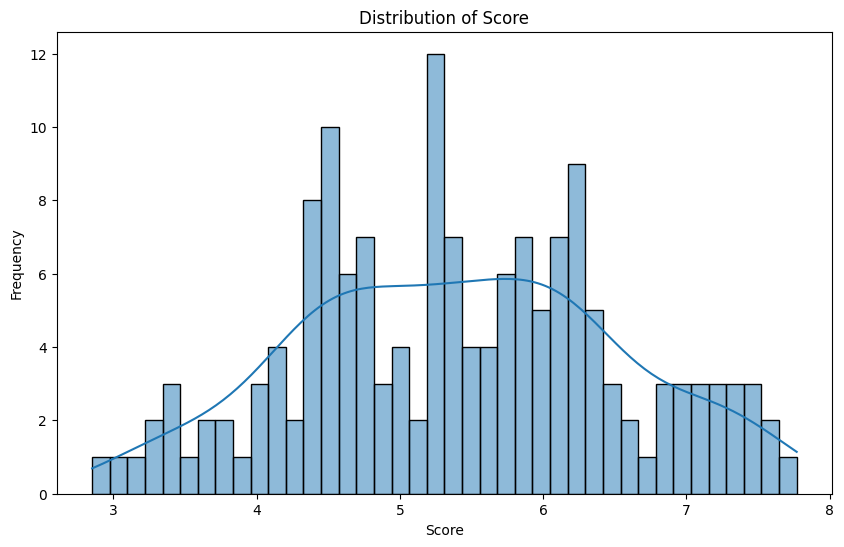

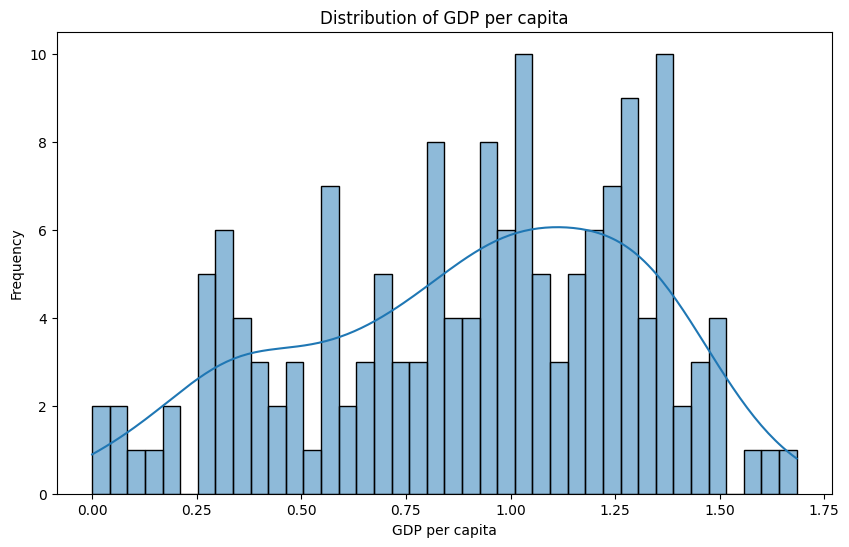

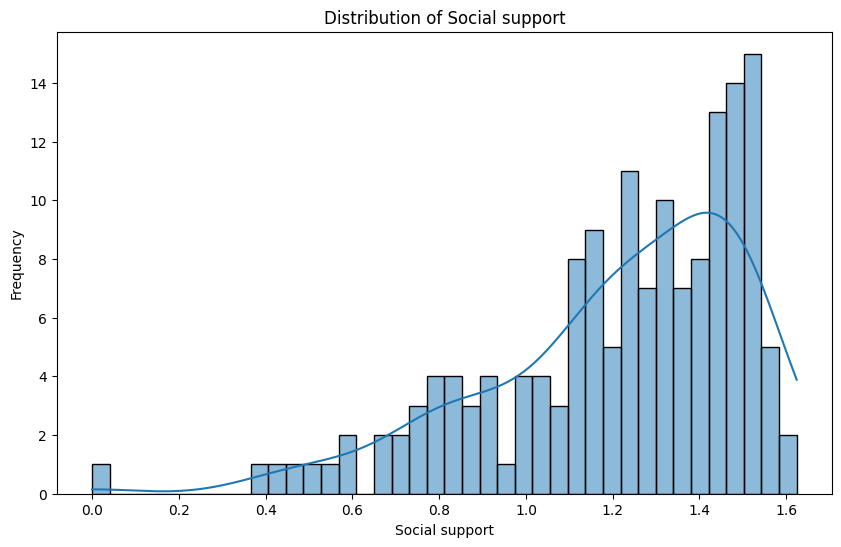

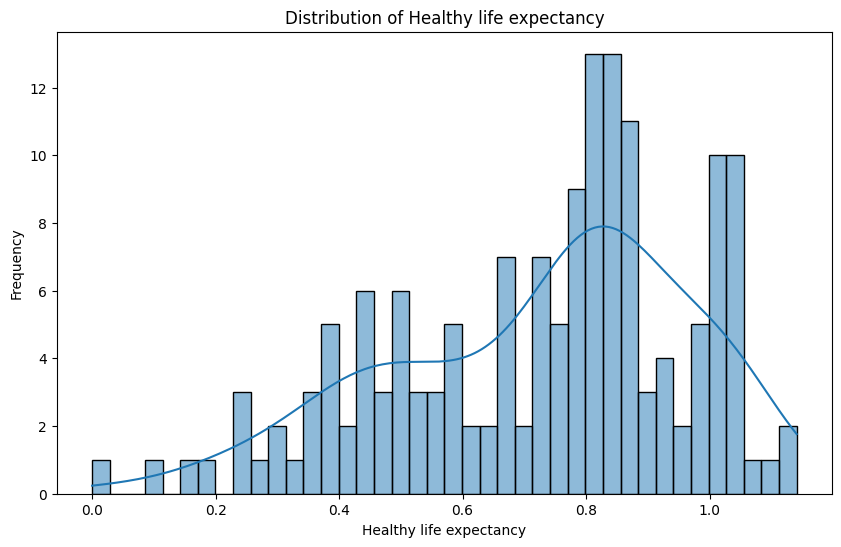

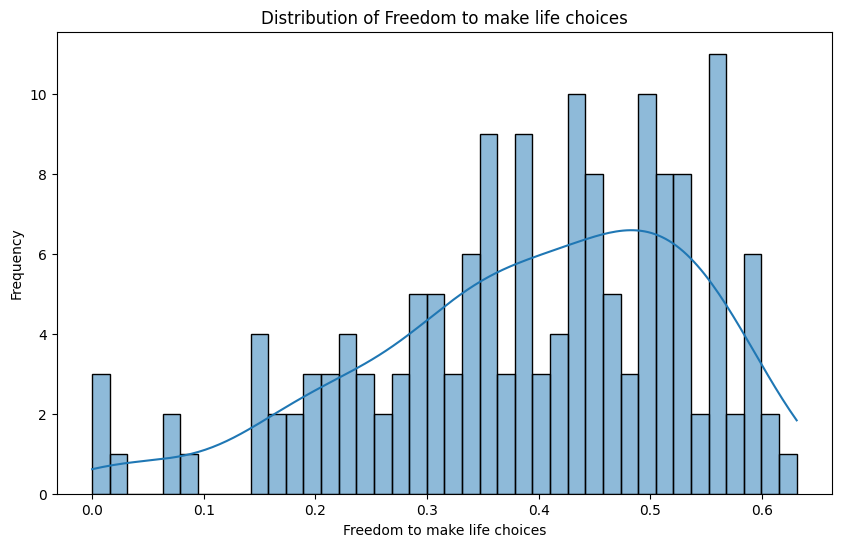

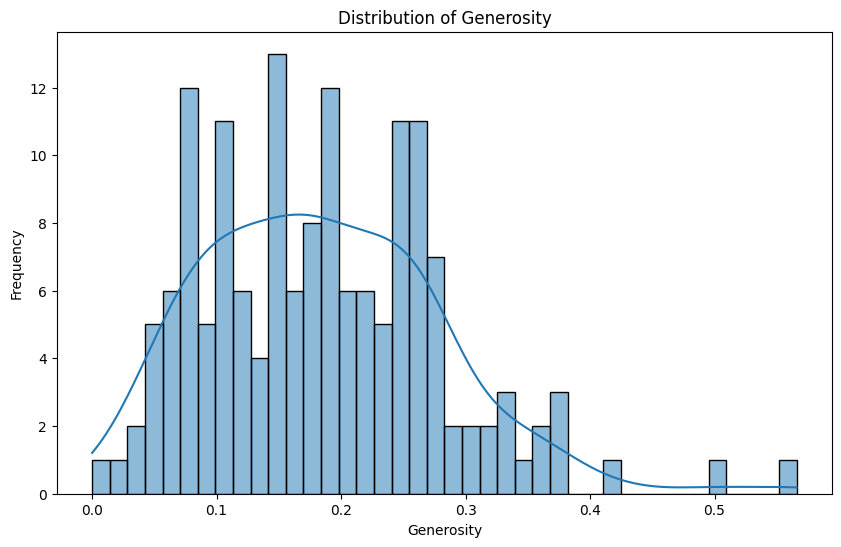

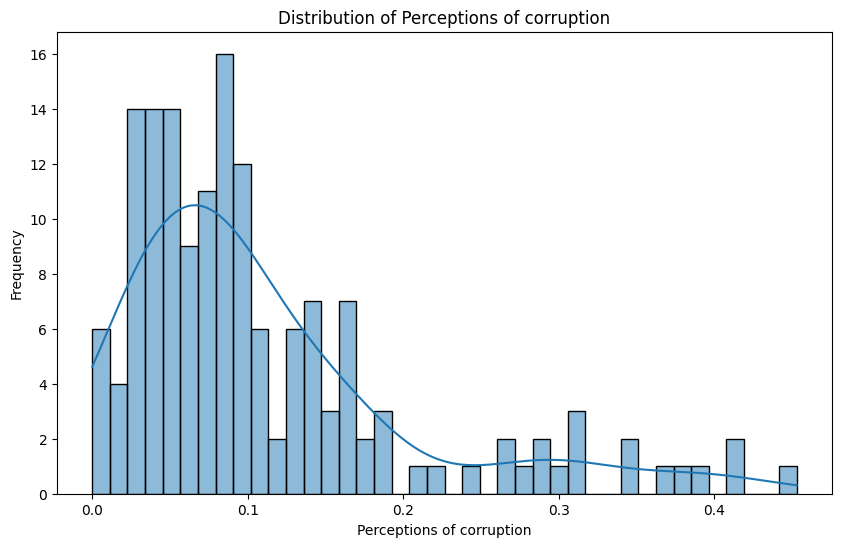

In [ ]:
columns = ['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

for col in columns:
  plt.figure(figsize=(10,6))
  sns.histplot(df[col], kde=True, bins=40)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()
  print("\n")

In [ ]:
df = df.rename(columns={'Country or region':'Country'})

Top 10 Happiest Countries

In [40]:
top_happiest_countries = df.nlargest(10, 'Score')
top_happiest_countries

,Overall rank,Country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


<function matplotlib.pyplot.show(close=None, block=None)>

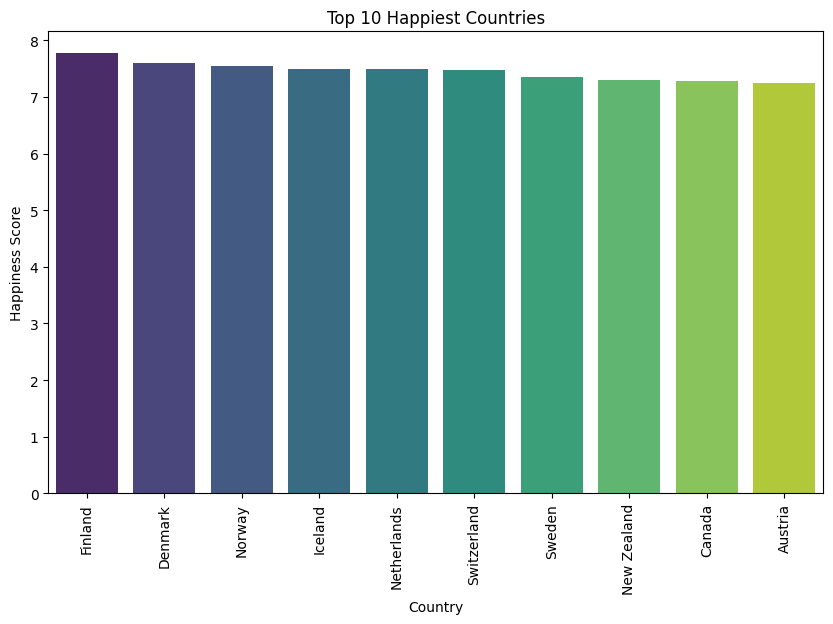

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(x='Country', hue='Country', y='Score', data=top_happiest_countries, palette='viridis')
plt.title('Top 10 Happiest Countries')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=90)
plt.show

Top 10 Unhappiest Countries

In [44]:
top_unhappiest_countries = df.nsmallest(10, 'Score')
top_unhappiest_countries

,Overall rank,Country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
150,151,Yemen,3.380,0.287,1.163,0.463,0.143,0.108,0.077
149,150,Malawi,3.410,0.191,0.560,0.495,0.443,0.218,0.089
148,149,Syria,3.462,0.619,0.378,0.440,0.013,0.331,0.141
147,148,Botswana,3.488,1.041,1.145,0.538,0.455,0.025,0.100
146,147,Haiti,3.597,0.323,0.688,0.449,0.026,0.419,0.110


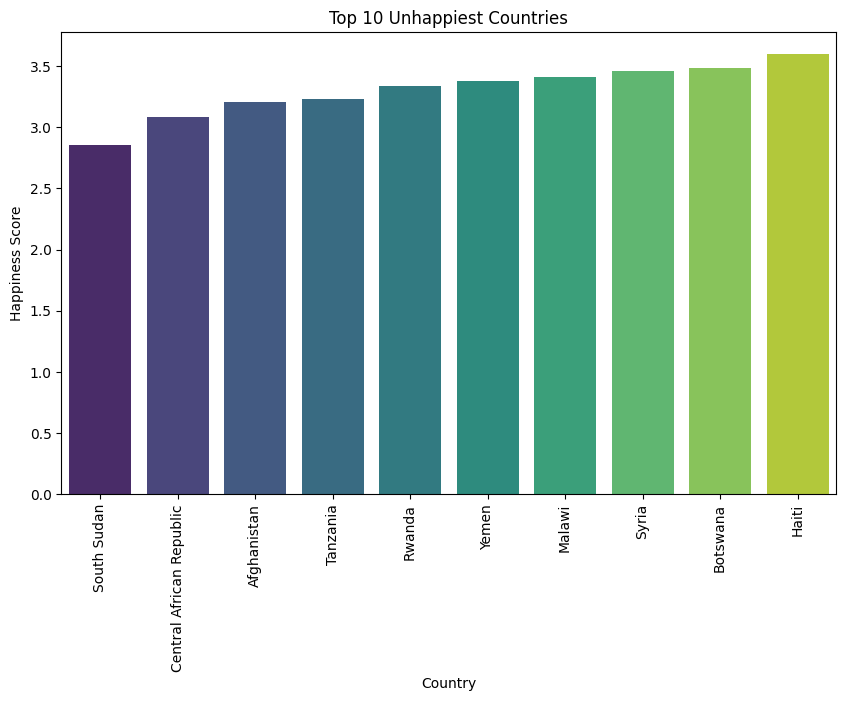

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_unhappiest_countries, x='Country', y='Score', hue='Country', palette='viridis')
plt.title("Top 10 Unhappiest Countries")
plt.xlabel("Country")
plt.ylabel("Happiness Score")
plt.xticks(rotation=90)
plt.show()

Correlation Analysis

<Axes: >

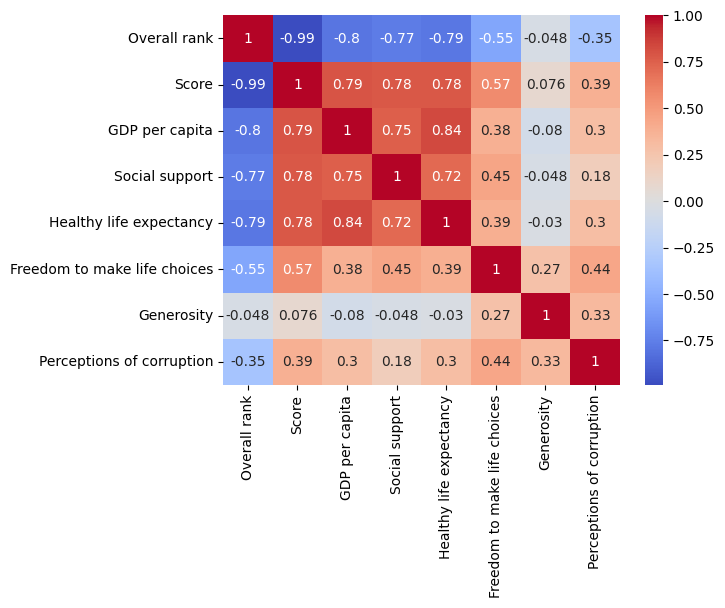

In [49]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

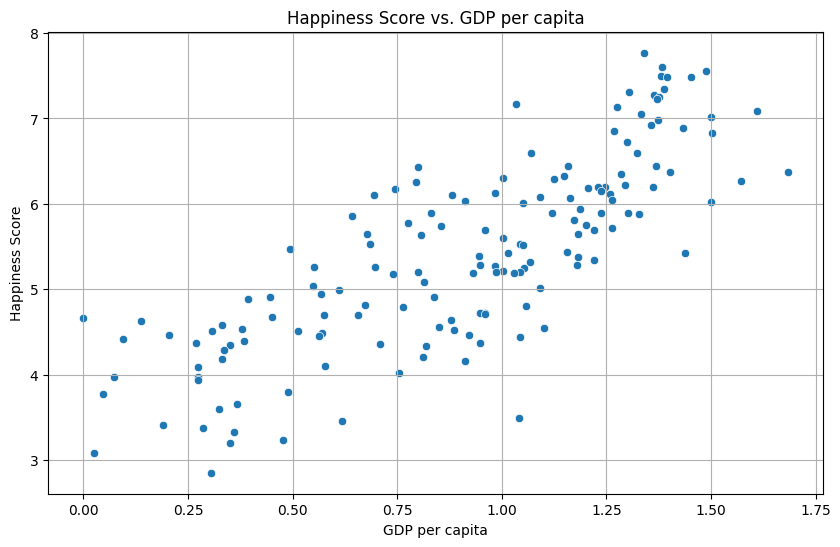

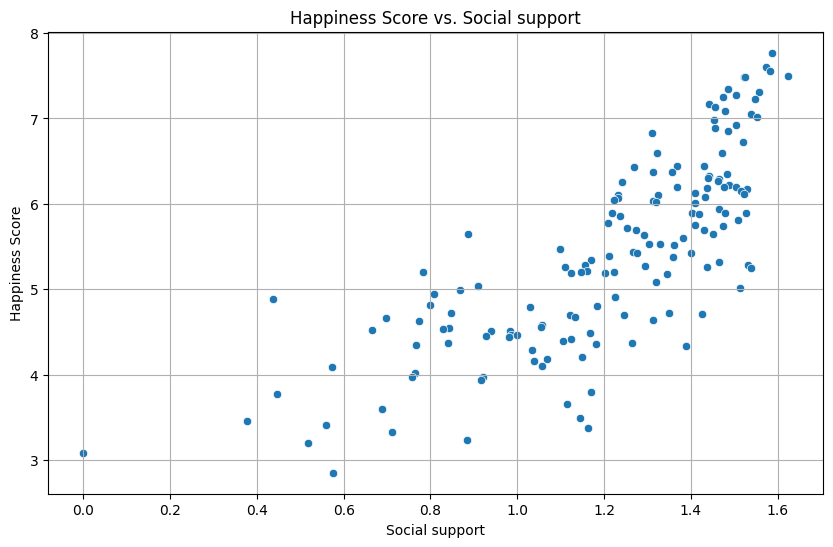

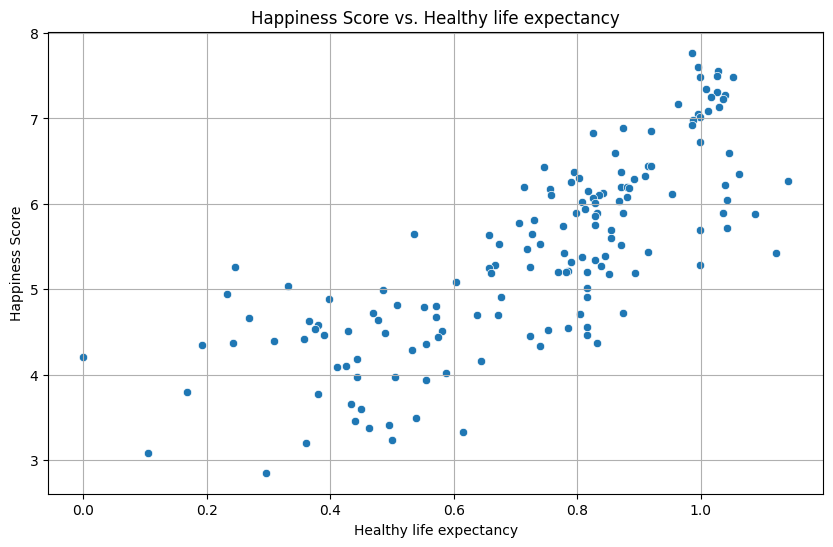

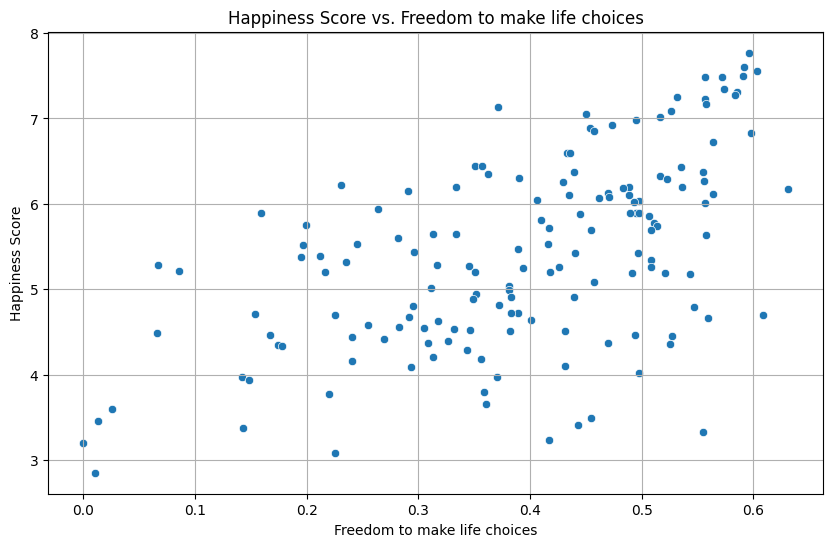

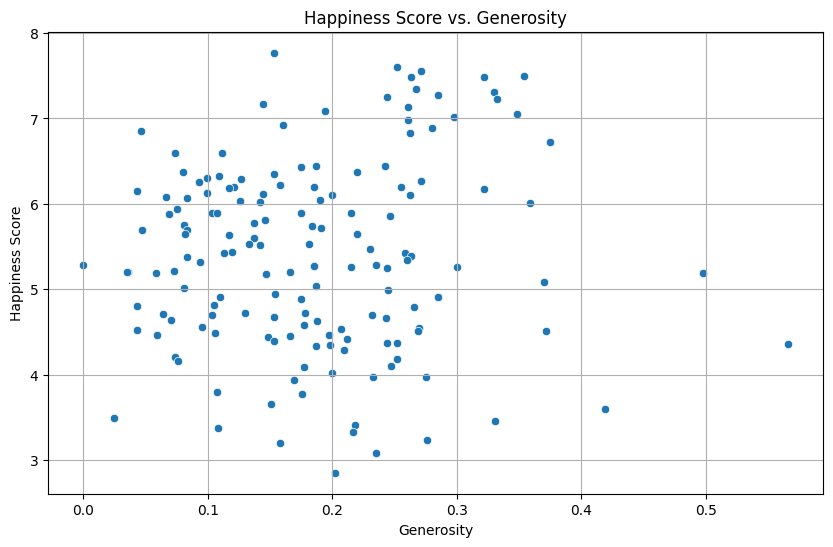

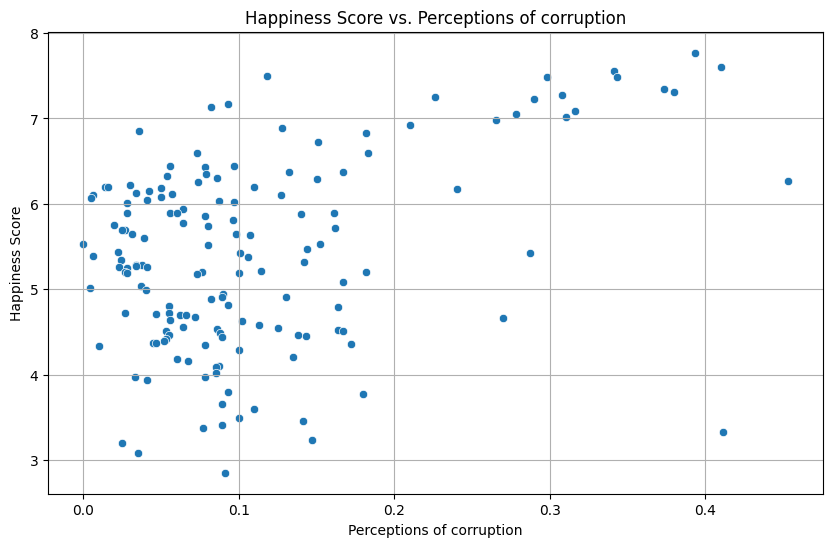

In [55]:
Features =['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

for feature in Features:
  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=feature, y='Score', data=df)
  plt.title(f'Happiness Score vs. {feature}')
  plt.xlabel(feature)
  plt.ylabel('Happiness Score')
  plt.grid(True)
  plt.show()
  print("\n")

### **Insights from Data Analysis:**

Based on the visualizations, here are some key observations:

#### **1. Data Distributions:**

*   **Happiness Score:** The distribution of happiness scores appears to be relatively normal, slightly skewed to the left, indicating that more countries tend to have higher happiness scores, but there's a significant spread.
*   **GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices:** These factors generally show a distribution skewed to the right, suggesting that a larger number of countries have lower values for these indicators, with fewer countries having very high values.
*   **Generosity and Perceptions of corruption:** These factors tend to be skewed heavily to the right, indicating that most countries have lower scores for generosity and lower perceptions of corruption (meaning higher perceived corruption, or lower scores on the index mean less corruption). More detailed interpretation would require understanding the scale of these metrics.

#### **2. Top 10 Happiest Countries:**

*   The top 10 happiest countries are predominantly European, with New Zealand and Canada also making the list.
*   Finland consistently ranks as the happiest country with the highest score.
*   These countries generally exhibit high scores across all contributing factors like GDP per capita, social support, healthy life expectancy, and freedom to make life choices.

#### **3. Top 10 Unhappiest Countries:**

*   The top 10 unhappiest countries are mostly located in Africa and the Middle East.
*   South Sudan, Central African Republic, and Afghanistan have the lowest happiness scores.
*   These countries typically show very low values across multiple contributing factors, especially social support, healthy life expectancy, and freedom to make life choices, and often have higher perceptions of corruption.

#### **4. Correlation Analysis:**

*   **Strong Positive Correlations with Happiness Score:**
    *   `GDP per capita`: There is a very strong positive correlation between GDP per capita and happiness score (around 0.79).
    *   `Social support`: Social support also shows a very strong positive correlation with happiness score (around 0.78).
    *   `Healthy life expectancy`: A strong positive correlation exists between healthy life expectancy and happiness score (around 0.77).
    *   `Freedom to make life choices`: This factor also has a significant positive correlation with happiness score (around 0.57).
*   **Weaker or Moderate Correlations with Happiness Score:**
    *   `Generosity`: Shows a weak positive correlation (around 0.07).
    *   `Perceptions of corruption`: Shows a moderate negative correlation (around -0.38), meaning higher corruption perception tends to be associated with lower happiness scores.
*   **Inter-feature Correlations:** Many of the highly correlated features (GDP, social support, healthy life expectancy, freedom) also show strong positive correlations among themselves, suggesting these factors often co-exist at high levels.

#### **5. Feature vs. Happiness Score Scatter Plots:**

*   **GDP per capita vs. Score:** A clear positive linear relationship is observed. Countries with higher GDP per capita tend to have higher happiness scores.
*   **Social support vs. Score:** A strong positive linear relationship, similar to GDP, indicating that better social support systems correlate with higher happiness.
*   **Healthy life expectancy vs. Score:** Another strong positive linear trend, suggesting that longer and healthier lives are associated with greater happiness.
*   **Freedom to make life choices vs. Score:** A positive but slightly less linear relationship, showing that more freedom generally leads to higher happiness, though with more scatter.
*   **Generosity vs. Score:** This plot shows a very weak or almost no clear linear relationship, reinforcing the low correlation found in the heatmap.
*   **Perceptions of corruption vs. Score:** A negative trend is visible, where countries with lower `Perceptions of corruption` values (meaning higher perceived integrity/less corruption) tend to have higher happiness scores, confirming the moderate negative correlation.